In [37]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

# plt.style.use('default')
sns.set_theme()


In [38]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator

In [39]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [40]:
domain = "humanoid"

In [41]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [42]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [43]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "mass_analysis" not in run.tags:
        continue

    # if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
    #     continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    # train_avg_episode_returns_history = run.scan_history(keys=["train/episode_reward"])
    # train_avg_episode_reward = [
    #     row["train/episode_reward"] for row in train_avg_episode_returns_history
    # ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # update_steps_history = run.scan_history(keys=["train/update_step"])
    # update_steps = [row["train/update_step"] for row in update_steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # print("len(update_steps): ", len(update_steps))
    # print("len(train_avg_episode_reward: ", len(train_avg_episode_reward))
    # print("len(train_avg_episode_reward): ", len(train_avg_episode_reward))
    #
    # print(update_steps[0])
    # print(train_avg_episode_reward[0])

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/step"] = steps
    # temp["train/update_step"] = update_steps
    temp["eval/episode_reward"] = avg_episode_reward
    # temp["train/episode_reward"] = train_avg_episode_reward

    # if "attention" in run.config["agent_name"]:
    #     #attention 1
    #     # attention_7_history_1 = run.scan_history(keys=["train/attention_distribution1_u_7_mean"])
    #     # attention_7_1 = [row["train/attention_distribution1_u_7_mean"] for row in attention_7_history_1]
    #     #
    #     # attention_6_history_1 = run.scan_history(keys=["train/attention_distribution1_u_6_mean"])
    #     # attention_6_1 = [row["train/attention_distribution1_u_6_mean"] for row in attention_6_history_1]
    #     #
    #     # attention_5_history_1 = run.scan_history(keys=["train/attention_distribution1_u_5_mean"])
    #     # attention_5_1 = [row["train/attention_distribution1_u_5_mean"] for row in attention_5_history_1]
    #     #
    #     # attention_4_history_1 = run.scan_history(keys=["train/attention_distribution1_u_4_mean"])
    #     # attention_4_1 = [row["train/attention_distribution1_u_4_mean"] for row in attention_4_history_1]
    #
    #     attention_3_history_1 = run.scan_history(keys=["train/attention_distribution1_u_3_mean"])
    #     attention_3_1 = [row["train/attention_distribution1_u_3_mean"] for row in attention_3_history_1]
    #
    #     attention_2_history_1 = run.scan_history(keys=["train/attention_distribution1_u_2_mean"])
    #     attention_2_1 = [row["train/attention_distribution1_u_2_mean"] for row in attention_2_history_1]
    #
    #     attention_1_history_1 = run.scan_history(keys=["train/attention_distribution1_u_1_mean"])
    #     attention_1_1 = [row["train/attention_distribution1_u_1_mean"] for row in attention_1_history_1]
    #
    #     attention_0_history_1 = run.scan_history(keys=["train/attention_distribution1_u_0_mean"])
    #     attention_0_1 = [row["train/attention_distribution1_u_0_mean"] for row in attention_0_history_1]
    #
    #     #attention 2
    #     # attention_7_history_2 = run.scan_history(keys=["train/attention_distribution2_u_7_mean"])
    #     # attention_7_2 = [row["train/attention_distribution2_u_7_mean"] for row in attention_7_history_2]
    #     #
    #     # attention_6_history_2 = run.scan_history(keys=["train/attention_distribution2_u_6_mean"])
    #     # attention_6_2 = [row["train/attention_distribution2_u_6_mean"] for row in attention_6_history_2]
    #     #
    #     # attention_5_history_2 = run.scan_history(keys=["train/attention_distribution2_u_5_mean"])
    #     # attention_5_2 = [row["train/attention_distribution2_u_5_mean"] for row in attention_5_history_2]
    #     #
    #     # attention_4_history_2 = run.scan_history(keys=["train/attention_distribution2_u_4_mean"])
    #     # attention_4_2 = [row["train/attention_distribution2_u_4_mean"] for row in attention_4_history_2]
    #
    #     attention_3_history_2 = run.scan_history(keys=["train/attention_distribution2_u_3_mean"])
    #     attention_3_2 = [row["train/attention_distribution2_u_3_mean"] for row in attention_3_history_2]
    #
    #     attention_2_history_2 = run.scan_history(keys=["train/attention_distribution2_u_2_mean"])
    #     attention_2_2 = [row["train/attention_distribution2_u_2_mean"] for row in attention_2_history_2]
    #
    #     attention_1_history_2 = run.scan_history(keys=["train/attention_distribution2_u_1_mean"])
    #     attention_1_2 = [row["train/attention_distribution2_u_1_mean"] for row in attention_1_history_2]
    #
    #     attention_0_history_2 = run.scan_history(keys=["train/attention_distribution2_u_0_mean"])
    #     attention_0_2 = [row["train/attention_distribution2_u_0_mean"] for row in attention_0_history_2]
    #
    #     # attention_7_1.insert(0, 0)
    #     # attention_6_1.insert(0, 0)
    #     # attention_5_1.insert(0, 0)
    #     # attention_4_1.insert(0, 0)
    #     attention_3_1.insert(0, 0)
    #     attention_2_1.insert(0, 0)
    #     attention_1_1.insert(0, 0)
    #     attention_0_1.insert(0, 0)
    #
    #     # attention_7_2.insert(0, 0)
    #     # attention_6_2.insert(0, 0)
    #     # attention_5_2.insert(0, 0)
    #     # attention_4_2.insert(0, 0)
    #     attention_3_2.insert(0, 0)
    #     attention_2_2.insert(0, 0)
    #     attention_1_2.insert(0, 0)
    #     attention_0_2.insert(0, 0)
    #
    #     # temp["train/attention_distribution1_u_7_mean"] = attention_7_1
    #     # temp["train/attention_distribution1_u_6_mean"] = attention_6_1
    #     # temp["train/attention_distribution1_u_5_mean"] = attention_5_1
    #     # temp["train/attention_distribution1_u_4_mean"] = attention_4_1
    #     temp["train/attention_distribution1_u_3_mean"] = attention_3_1
    #     temp["train/attention_distribution1_u_2_mean"] = attention_2_1
    #     temp["train/attention_distribution1_u_1_mean"] = attention_1_1
    #     temp["train/attention_distribution1_u_0_mean"] = attention_0_1
    #
    #     # temp["train/attention_distribution2_u_7_mean"] = attention_7_2
    #     # temp["train/attention_distribution2_u_6_mean"] = attention_6_2
    #     # temp["train/attention_distribution2_u_5_mean"] = attention_5_2
    #     # temp["train/attention_distribution2_u_4_mean"] = attention_4_2
    #     temp["train/attention_distribution2_u_3_mean"] = attention_3_2
    #     temp["train/attention_distribution2_u_2_mean"] = attention_2_2
    #     temp["train/attention_distribution2_u_1_mean"] = attention_1_2
    #     temp["train/attention_distribution2_u_0_mean"] = attention_0_2
    #
    # else:
    #     zeros_list = [0] * len(steps)
    #     # temp["train/attention_distribution1_u_7_mean"] = zeros_list
    #     # temp["train/attention_distribution1_u_6_mean"] = zeros_list
    #     # temp["train/attention_distribution1_u_5_mean"] = zeros_list
    #     # temp["train/attention_distribution1_u_4_mean"] = zeros_list
    #     temp["train/attention_distribution1_u_3_mean"] = zeros_list
    #     temp["train/attention_distribution1_u_2_mean"] = zeros_list
    #     temp["train/attention_distribution1_u_1_mean"] = zeros_list
    #     temp["train/attention_distribution1_u_0_mean"] = zeros_list
    #
    #     # temp["train/attention_distribution2_u_7_mean"] = zeros_list
    #     # temp["train/attention_distribution2_u_6_mean"] = zeros_list
    #     # temp["train/attention_distribution2_u_5_mean"] = zeros_list
    #     # temp["train/attention_distribution2_u_4_mean"] = zeros_list
    #     temp["train/attention_distribution2_u_3_mean"] = zeros_list
    #     temp["train/attention_distribution2_u_2_mean"] = zeros_list
    #     temp["train/attention_distribution2_u_1_mean"] = zeros_list
    #     temp["train/attention_distribution2_u_0_mean"] = zeros_list
    #
    # print("len attention_0_1: ", len(temp["train/attention_distribution1_u_0_mean"]))

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 511
idx: 0
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
idx: 10
idx: 20
idx: 30
idx: 40
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
idx: 50
idx: 60
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
ddpg_beakers_params_continuous
len(steps):  

In [44]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

runs_df["percentage_shift_mass"] = runs_df["config"].apply(lambda x: x["percentage_shifts_mass"])

In [45]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ppo": "PPO"
}

In [46]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [47]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [48]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [49]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [50]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [51]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [52]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [53]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [54]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [55]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [56]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ppo", agents_new_names["ppo"]
)

In [57]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['TD3' 'TD3 + SC' 'SF + SC (Ours)' 'SF' 'SF + EWC' 'TD3 + EWC' 'TD3 + CBP'
 'TD3 + P-last']


In [58]:
print(runs_df)

                                               summary  \
0    {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
1    {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
2    {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
3    {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
4    {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
..                                                 ...   
143  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
144  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
145  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
146  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
147  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   

                                                config  \
0    {'mode': 'full_train_run_forward', 'seed': 97,...   
1    {'mode': 'full_train_run_forward', 'seed': 388...   
2    {'mode': 'full_train_run_forward', 'seed': 485...   
3    {'mode': 'full_train_run_forward', 'seed': 679...   
4    {'mode':

In [59]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed', 'percentage_shift_mass']


In [60]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (148, 6)


In [61]:
print(runs_df.columns[2:])



Index(['name', 'agent_name', 'agent_seed', 'percentage_shift_mass'], dtype='object')


In [62]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

    agent_name  agent_seed  percentage_shift_mass  \
0          TD3          97                  0.050   
1          TD3         388                  0.050   
2          TD3         485                  0.050   
3          TD3         679                  0.050   
4          TD3         194                  0.050   
..         ...         ...                    ...   
143         SF         582                  0.025   
144         SF         679                  0.025   
145         SF          97                  0.050   
146         SF         194                  0.050   
147         SF         388                  0.050   

                                             eval/step  \
0    [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
1    [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
2    [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
3    [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
4    [0, 10000, 20000, 30000, 40000, 50000, 60000, ...   
..             

In [63]:
# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[3:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

(44400, 5)


In [64]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "PPO": "#17becf",
    # "SF + SC": "#ff7f0e",
    # "TD3 + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "TD3",
#     "ddpg_beakers_params_continuous": "TD3 + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "TD3 + Plasticity (last layer)",
#     "ddpg_online_ewc": "TD3 (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "TD3 + Plasticity",
# }

In [65]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(runs_df.columns)

runs_df["eval/episode_rewards_num"] = (
    runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "eval/step"])

runs_df["eval/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["eval/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["norm_cum_reward"] = runs_df["eval/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'percentage_shift_mass', 'eval/step',
       'eval/episode_reward'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'percentage_shift_mass', 'eval/step',
       'eval/episode_reward', 'eval/episode_rewards_num',
       'eval/cumulative_rewards', 'episode_count', 'norm_cum_reward',
       'agent_name_pretty'],
      dtype='object')


In [66]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

mass_scale_df = runs_df.copy()

print(mass_scale_df.columns)

mass_scale_df["eval/episode_rewards_num"] = (
    mass_scale_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

mass_scale_df = mass_scale_df.sort_values(["percentage_shift_mass", "agent_seed","eval/step"])

mass_scale_df["eval/cumulative_rewards"] = (
    mass_scale_df.groupby(["percentage_shift_mass","agent_seed"])["eval/episode_rewards_num"].cumsum()
)

mass_scale_df["episode_count"] = (
    mass_scale_df.groupby(["percentage_shift_mass","agent_seed", ]).cumcount() + 1
)

mass_scale_df["norm_cum_reward"] = mass_scale_df["eval/cumulative_rewards"] / mass_scale_df["episode_count"]

mass_scale_df["agent_name_pretty"] = mass_scale_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(mass_scale_df.columns)
# print(timescale_runs_df["agent_num_beakers","norm_cum_reward"])

Index(['agent_name', 'agent_seed', 'percentage_shift_mass', 'eval/step',
       'eval/episode_reward', 'eval/episode_rewards_num',
       'eval/cumulative_rewards', 'episode_count', 'norm_cum_reward',
       'agent_name_pretty'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'percentage_shift_mass', 'eval/step',
       'eval/episode_reward', 'eval/episode_rewards_num',
       'eval/cumulative_rewards', 'episode_count', 'norm_cum_reward',
       'agent_name_pretty'],
      dtype='object')


In [67]:
mass_scale_df_mild = mass_scale_df[mass_scale_df["percentage_shift_mass"] == 0.025]
mass_scale_df_moderate = mass_scale_df[mass_scale_df["percentage_shift_mass"] == 0.05]
mass_scale_df_severe = mass_scale_df[mass_scale_df["percentage_shift_mass"] == 0.1]

In [68]:
print(mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]][["eval/step", "eval/episode_reward"]])

       eval/step eval/episode_reward
16500          0            1.006805
16501      10000            1.121704
16502      20000            1.319633
16503      30000            1.708069
16504      40000            1.541054
...          ...                 ...
18595  2950000.0          850.356474
18596  2960000.0          880.012931
18597  2970000.0          908.736542
18598  2980000.0          872.233608
18599  2990000.0          914.618849

[2100 rows x 2 columns]


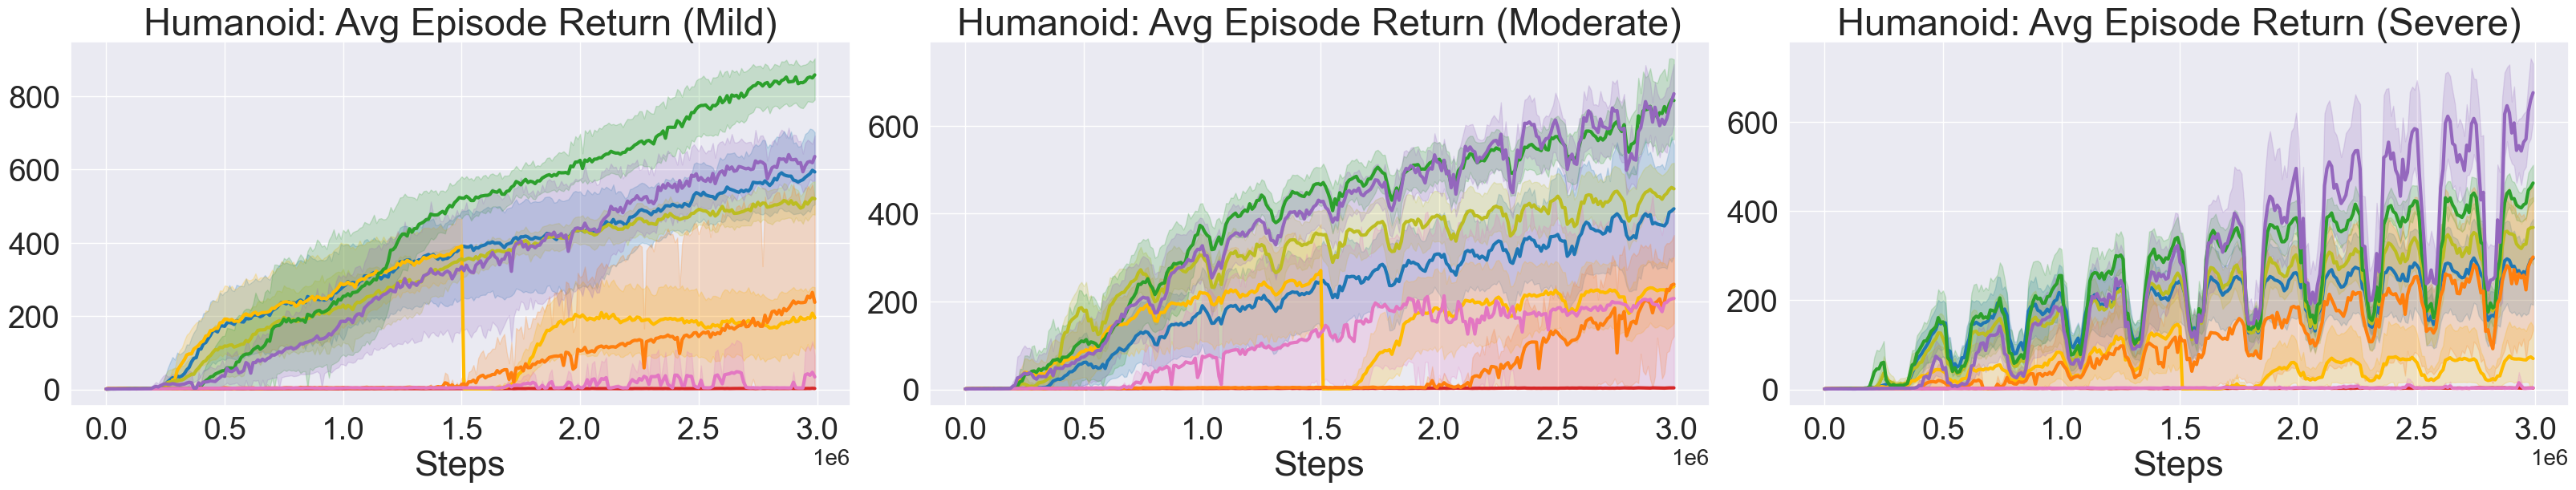

In [69]:
# Comparing with different quantification of mass
fig, axes = plt.subplots(1, 3, figsize=(32, 6), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_mild[mass_scale_df_mild["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


# MODERATE
sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_moderate[mass_scale_df_moderate["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

# SEVERE

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=mass_scale_df_severe[mass_scale_df_severe["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[2],
)

axes[0].set_title("Humanoid: Avg Episode Return (Mild)", fontsize=34)
axes[0].set_xlabel("Steps", fontsize=32)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=20)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=28)
axes[0].tick_params(axis="y", labelsize=28)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_title("Humanoid: Avg Episode Return (Moderate)", fontsize=34)
axes[1].set_xlabel("Steps", fontsize=32)
axes[1].set_ylabel("", fontsize=30)
# axes[1].legend(loc="upper left", fontsize=20)
axes[1].legend().set_visible(False)
axes[1].tick_params(axis="x", labelsize=28)
axes[1].tick_params(axis="y", labelsize=28)
axes[1].xaxis.get_offset_text().set_fontsize(20)

axes[2].set_title("Humanoid: Avg Episode Return (Severe)", fontsize=34)
axes[2].set_xlabel("Steps", fontsize=32)
axes[2].set_ylabel("", fontsize=30)
# axes[2].legend(loc="upper left", fontsize=20)
axes[2].legend().set_visible(False)
axes[2].tick_params(axis="x", labelsize=28)
axes[2].tick_params(axis="y", labelsize=28)
axes[2].xaxis.get_offset_text().set_fontsize(20)

filename = "mass_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


In [70]:
from scipy.integrate import trapezoid

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])

auc_mass_scale_df_mild = (
    mass_scale_df_mild.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

auc_mass_scale_df_moderate = (
    mass_scale_df_moderate.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

auc_mass_scale_df_severe = (
    mass_scale_df_severe.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

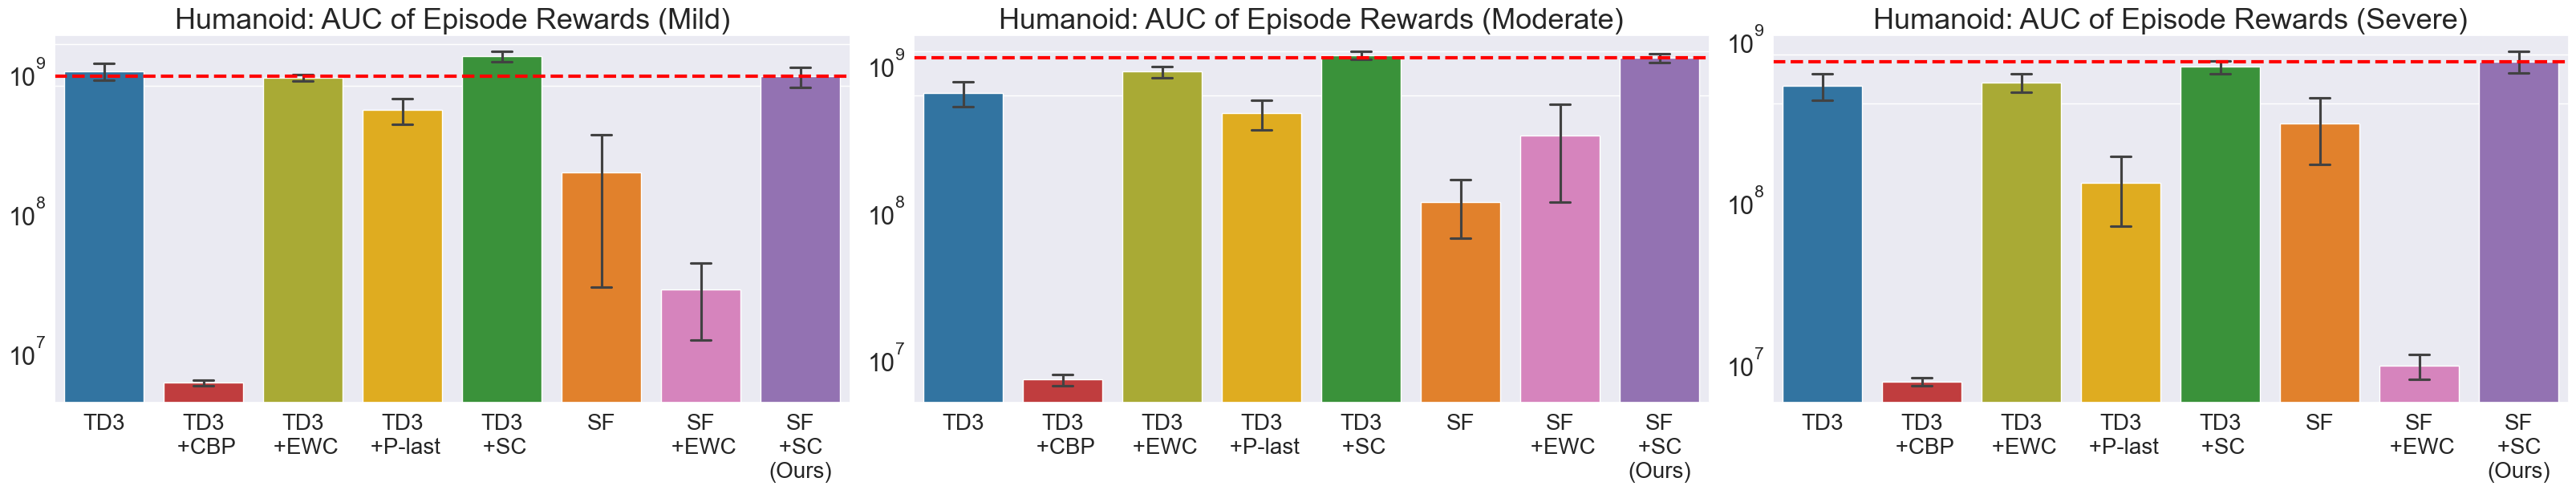

In [81]:
from matplotlib.ticker import MaxNLocator, LogLocator
# Comparing with different quantification of mass
fig, axes = plt.subplots(1, 3, figsize=(32, 6), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)

agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + P-last", "TD3 + SC", "SF", "SF + EWC",  "SF + SC (Ours)",]
subset_mild = auc_mass_scale_df_mild[auc_mass_scale_df_mild["agent_name"].isin(agents_to_plot)]
subset_mild["agent_name_pretty"] = subset_mild["agent_name"].str.replace(" + ", "\n +", regex=False)
subset_mild["agent_name_pretty"] = subset_mild["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"
subset_mild["agent_name_pretty"] = pd.Categorical(subset_mild["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
eps = 1e-12  # in case any values are 0
subset_mild = subset_mild.copy()
# subset_mild["AUC_log10"] = np.log10(subset_mild["AUC"].clip(lower=eps))

subset_moderate = auc_mass_scale_df_moderate[auc_mass_scale_df_moderate["agent_name"].isin(agents_to_plot)]
subset_moderate["agent_name_pretty"] = subset_moderate["agent_name"].str.replace(" + ", "\n +", regex=False)
subset_moderate["agent_name_pretty"] = subset_moderate["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)

subset_moderate["agent_name_pretty"] = pd.Categorical(subset_moderate["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)

subset_moderate = subset_moderate.copy()
# subset_moderate["AUC_log10"] = np.log10(subset_moderate["AUC"].clip(lower=eps))

subset_severe = auc_mass_scale_df_severe[auc_mass_scale_df_severe["agent_name"].isin(agents_to_plot)]
subset_severe["agent_name_pretty"] = subset_severe["agent_name"].str.replace(" + ", "\n +", regex=False)
subset_severe["agent_name_pretty"] = subset_severe["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
subset_severe["agent_name_pretty"] = pd.Categorical(subset_severe["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)

subset_severe = subset_severe.copy()
# subset_severe["AUC_log10"] = np.log10(subset_severe["AUC"].clip(lower=eps))


ax_mild = sns.barplot(data=subset_mild, x="agent_name_pretty", y="AUC", palette=color_code, ax=axes[0], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)

ax_moderate = sns.barplot(data=subset_moderate, x="agent_name_pretty", y="AUC", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)

ax_severe = sns.barplot(data=subset_severe, x="agent_name_pretty", y="AUC", palette=color_code, ax=axes[2], errorbar="se", capsize=0.2, hue="agent_name_pretty", clip_on=True)

mean_val_mild = subset_mild[subset_mild["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax_mild.axhline(mean_val_mild, color="red", linestyle="--", linewidth=3)

mean_val_moderate = subset_moderate[subset_moderate["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax_moderate.axhline(mean_val_moderate, color="red", linestyle="--", linewidth=3)

mean_val_severe = subset_severe[subset_severe["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax_severe.axhline(mean_val_severe, color="red", linestyle="--", linewidth=3)

axes[0].set_xlabel("", fontsize=20)
axes[0].set_ylabel("", fontsize=20)
axes[0].set_title("Humanoid: AUC of Episode Rewards (Mild)", fontsize=26)
axes[0].tick_params(axis="x", labelsize=20)
axes[0].tick_params(axis="y", labelsize=22)
axes[0].set_yscale("log")
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[0].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[0].tick_params(axis='y', which='both', labelsize=22)


axes[1].set_xlabel("", fontsize=20)
axes[1].set_ylabel("", fontsize=20)
axes[1].set_title("Humanoid: AUC of Episode Rewards (Moderate)", fontsize=26)
axes[1].tick_params(axis="x", labelsize=20)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[1].tick_params(axis='y', which='both', labelsize=22)
axes[1].tick_params(axis='y', which='major', labelsize=0)

axes[2].set_xlabel("", fontsize=20)
axes[2].set_ylabel("", fontsize=22)
axes[2].set_title("Humanoid: AUC of Episode Rewards (Severe)", fontsize=26)
axes[2].tick_params(axis="x", labelsize=20)
axes[2].tick_params(axis="y", labelsize=22)
axes[2].set_yscale("log")
axes[2].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[2].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))
axes[2].tick_params(axis='y', which='both', labelsize=22)


filename = "mass_analysis_auc_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


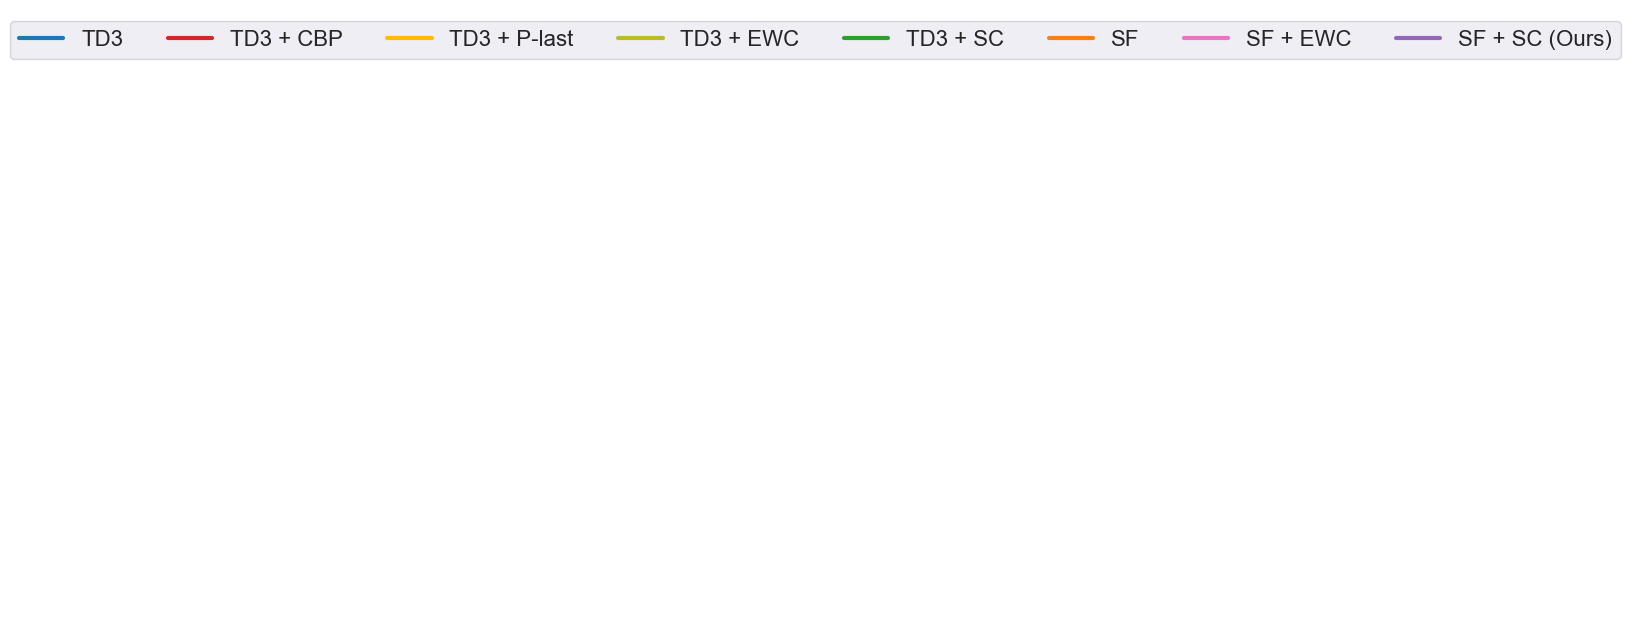

In [86]:
"""
This plot is only used for making legends!!!!
"""

# Plot for Plasticity-Stability Analysis

# from matplotlib.ticker import MaxNLocator, LogLocator
# plt.close()
# fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
#     label=agents_new_names["ddpg_continual_backprop"],
#     color=color_code[agents_new_names["ddpg_continual_backprop"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     label=agents_new_names["ddpg_plasticity_injection_last_layer"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
#     label=agents_new_names["ddpg_online_ewc"],
#     color=color_code[agents_new_names["ddpg_online_ewc"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
#     label=agents_new_names["ddpg_beakers_params_continuous"],
#     color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
#     label=agents_new_names["sf_simple_beakers_params"],
#     color=color_code[agents_new_names["sf_simple_beakers_params"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# xline = 1e6
# ymin, ymax = ax.get_ylim()
#
# ax.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
# ax.text(
#     xline,                      # x position (same as line)
#     ymin + 0.3* (ymax - ymin),   # 40% above the bottom,
#     "Plasticity Inj.",
#     rotation=90,                # vertical text
#     color="red",
#     ha="right", va="top",       # horizontal/vertical alignment
#     fontsize=18
# )
#
# # plt.title("Half-Cheetah: Avg Episode Return", fontsize=26)
# plt.xlabel("Steps", fontsize=30)
# plt.ylabel("", fontsize=30)
# # plt.legend(loc="upper left", fontsize=16, ncol=2)
# plt.legend(
#     loc="upper center",          # center horizontally
#     bbox_to_anchor=(0.5, 1),  # (x=0.5 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ center, y>1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ move upward)
#     fontsize=16,
#     ncol=2                       # optional: make legend entries spread in columns
# )
# plt.xticks(fontsize=25)
# plt.yticks(fontsize=25)
# ax.xaxis.get_offset_text().set_fontsize(20)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=5))


from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color=color_code[agents_new_names["ddpg"]], lw=3, label=agents_new_names["ddpg"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_continual_backprop"]], lw=3, label=agents_new_names["ddpg_continual_backprop"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]], lw=3, label=agents_new_names["ddpg_plasticity_injection_last_layer"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_online_ewc"]], lw=3, label=agents_new_names["ddpg_online_ewc"]),
    Line2D([0], [0], color=color_code[agents_new_names["ddpg_beakers_params_continuous"]], lw=3, label=agents_new_names["ddpg_beakers_params_continuous"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_simple"]], lw=3, label=agents_new_names["sf_simple"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_online_ewc"]], lw=3, label=agents_new_names["sf_online_ewc"]),
    Line2D([0], [0], color=color_code[agents_new_names["sf_simple_beakers_params"]], lw=3, label=agents_new_names["sf_simple_beakers_params"]),
]

fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")               # hide axes
plt.legend(
    handles=custom_lines,
    loc="upper center",          # center horizontally
    bbox_to_anchor=(0.5, 1),  # (x=0.5 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ center, y>1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ move upward)
    fontsize=16,
    ncol=8                       # optional: make legend entries spread in columns
)

filename = "mass_analysis_make_title" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf")
plt.show()
